<a href="https://colab.research.google.com/github/Pedrojorge11/Pedrojorge11/blob/main/VisaoComp1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visão Computacional

# Aluno: Pedro Jorge da Silva

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 12

print("Ambiente preparado com sucesso.")
print("OpenCV:", cv2.__version__)
print("Numpy:", np.__version__)

Ambiente preparado com sucesso.
OpenCV: 4.13.0
Numpy: 2.0.2


Imagem carregada com sucesso.
Formato da matriz da imagem: (1755, 1240, 3)


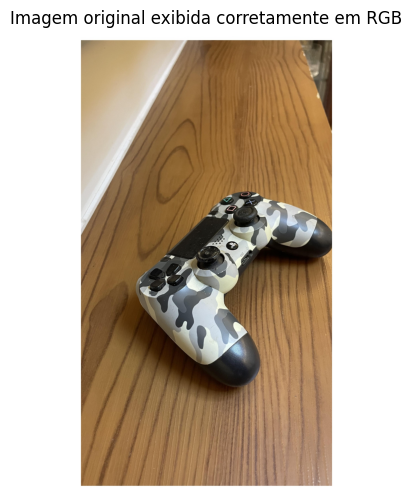

In [4]:
caminho_imagem = Path("minha_foto_real.jpg")

if not caminho_imagem.exists():
    print("Erro: Imagem não encontrada. Faça o upload no Colab.")
else:
    imagem_bgr = cv2.imread(str(caminho_imagem))
    print("Imagem carregada com sucesso.")
    print("Formato da matriz da imagem:", imagem_bgr.shape)

    imagem_rgb = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(imagem_rgb)
    plt.title("Imagem original exibida corretamente em RGB")
    plt.axis("off")
    plt.show()

Valor do limiar calculado automaticamente pelo Otsu: 176.0


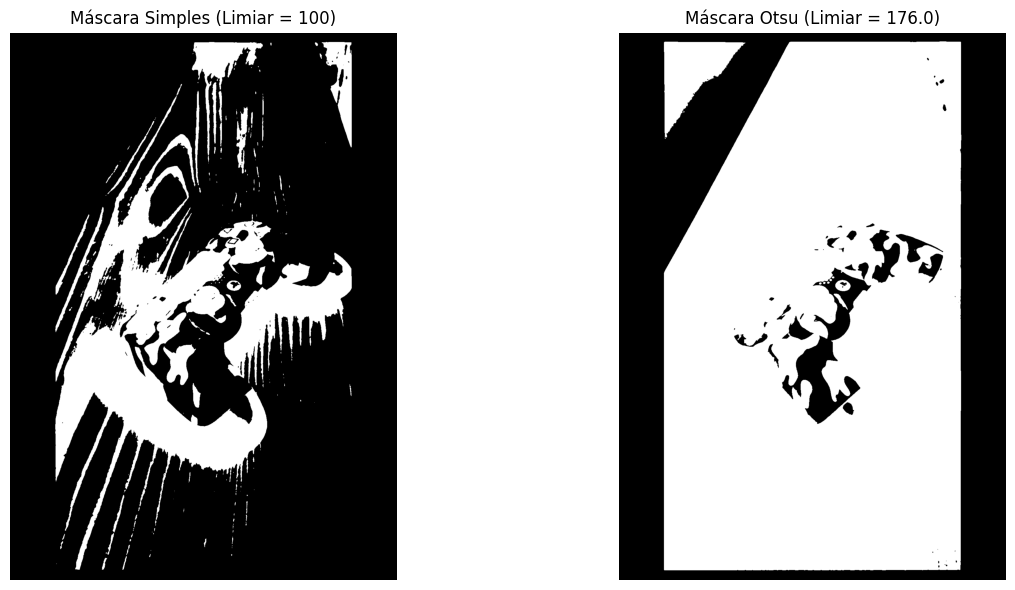

In [5]:
imagem_cinza = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2GRAY)
imagem_suavizada = cv2.GaussianBlur(imagem_cinza, (7, 7), 0)

# 1. Limiarização Simples (Testando o valor 100)
valor_limiar = 100
_, mascara_simples = cv2.threshold(imagem_suavizada, valor_limiar, 255, cv2.THRESH_BINARY_INV)

# 2. Limiarização por OTSU (Automático)
valor_otsu, mascara_otsu = cv2.threshold(imagem_suavizada, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
print(f"Valor do limiar calculado automaticamente pelo Otsu: {valor_otsu}")

# Comparando os dois resultados
fig, eixos = plt.subplots(1, 2, figsize=(14, 6))

eixos[0].imshow(mascara_simples, cmap="gray")
eixos[0].set_title(f"Máscara Simples (Limiar = {valor_limiar})")
eixos[0].axis("off")

eixos[1].imshow(mascara_otsu, cmap="gray")
eixos[1].set_title(f"Máscara Otsu (Limiar = {valor_otsu})")
eixos[1].axis("off")

plt.tight_layout()
plt.show()

# IMPORTANTE: Vamos usar a máscara do Otsu para a detecção de contornos a partir daqui
mascara_binaria = mascara_otsu

In [7]:
# Encontrando os contornos na máscara do Otsu
contornos, _ = cv2.findContours(mascara_binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Criando a variável que estava faltando!
imagem_detectada = imagem_rgb.copy()
area_minima = 300
regioes_detectadas = []

for contorno in contornos:
    area = cv2.contourArea(contorno)
    if area > area_minima:
        x, y, w, h = cv2.boundingRect(contorno)
        regioes_detectadas.append((x, y, w, h, area))

        # Desenhando o retângulo e o texto
        cv2.rectangle(imagem_detectada, (x, y), (x + w, y + h), (255, 0, 0), 3)
        cv2.putText(
            imagem_detectada,
            f"Area: {int(area)}",
            (x, max(y - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2,
            cv2.LINE_AA
        )

print("Quantidade de regiões relevantes detectadas:", len(regioes_detectadas))

Quantidade de regiões relevantes detectadas: 2


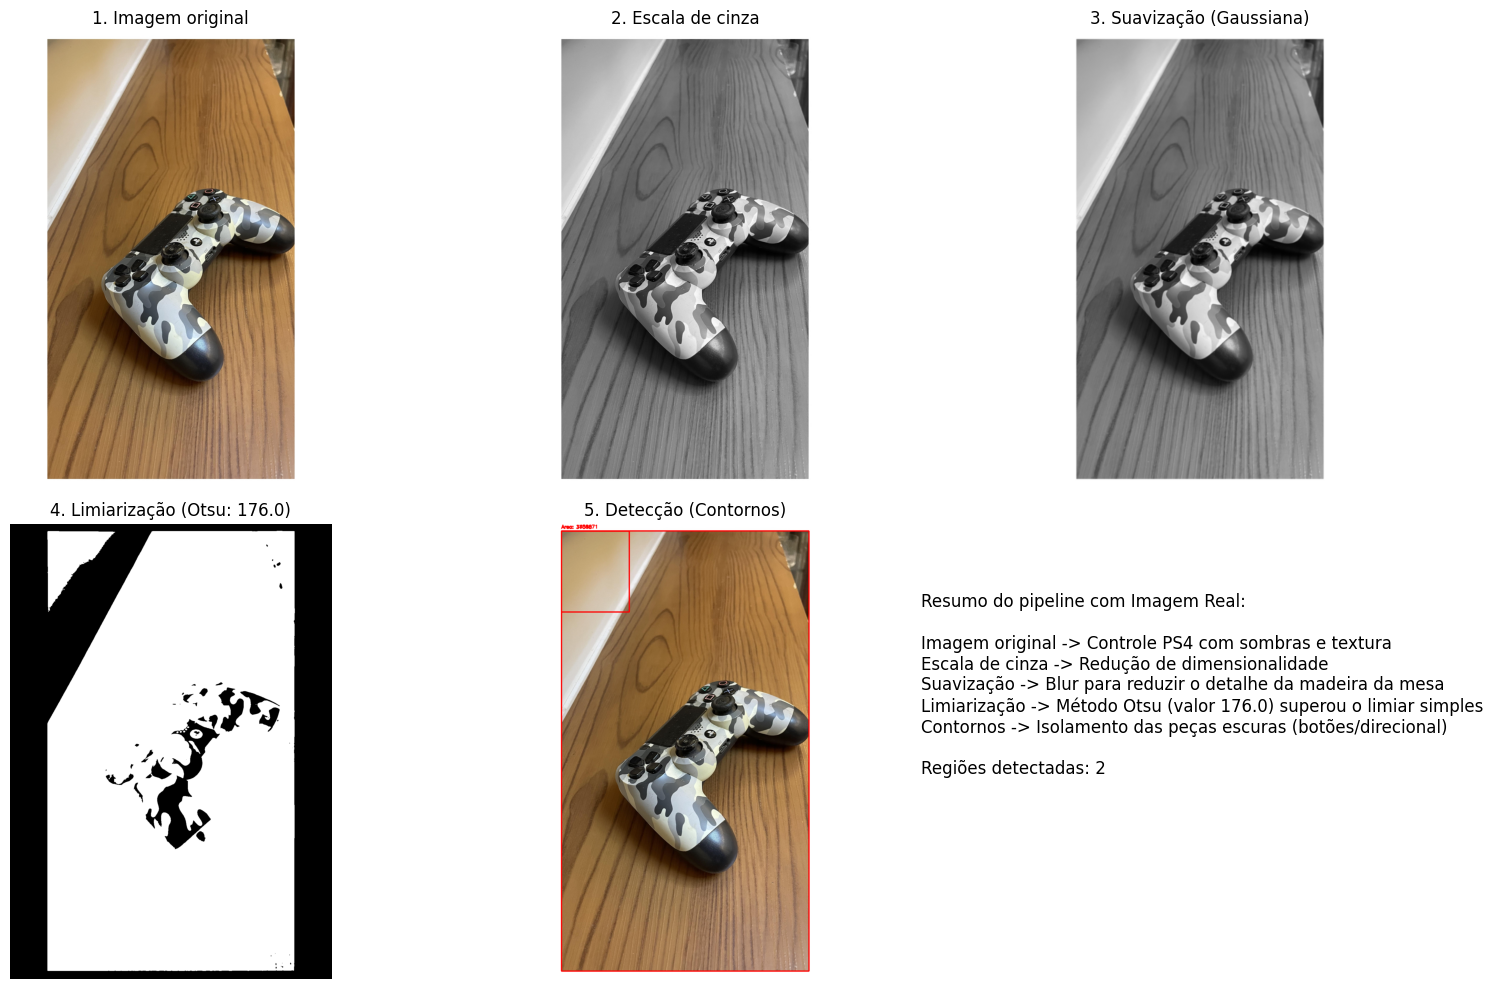

In [8]:
fig, eixos = plt.subplots(2, 3, figsize=(18, 10))

eixos[0, 0].imshow(imagem_rgb)
eixos[0, 0].set_title("1. Imagem original")
eixos[0, 0].axis("off")

eixos[0, 1].imshow(imagem_cinza, cmap="gray")
eixos[0, 1].set_title("2. Escala de cinza")
eixos[0, 1].axis("off")

eixos[0, 2].imshow(imagem_suavizada, cmap="gray")
eixos[0, 2].set_title("3. Suavização (Gaussiana)")
eixos[0, 2].axis("off")

eixos[1, 0].imshow(mascara_binaria, cmap="gray")
eixos[1, 0].set_title(f"4. Limiarização (Otsu: {valor_otsu})")
eixos[1, 0].axis("off")

eixos[1, 1].imshow(imagem_detectada)
eixos[1, 1].set_title("5. Detecção (Contornos)")
eixos[1, 1].axis("off")

eixos[1, 2].axis("off")
texto_resumo = (
    "Resumo do pipeline com Imagem Real:\n\n"
    "Imagem original -> Controle PS4 com sombras e textura\n"
    "Escala de cinza -> Redução de dimensionalidade\n"
    "Suavização -> Blur para reduzir o detalhe da madeira da mesa\n"
    f"Limiarização -> Método Otsu (valor {valor_otsu}) superou o limiar simples\n"
    "Contornos -> Isolamento das peças escuras (botões/direcional)\n\n"
    f"Regiões detectadas: {len(regioes_detectadas)}"
)

eixos[1, 2].text(0.02, 0.85, texto_resumo, fontsize=12, va="top")

plt.tight_layout()
plt.show()